In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
ad = pd.read_csv('advertising.csv')

In [ ]:
ad.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [ ]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [ ]:
ad.shape

(1000, 10)

In [ ]:
ad.isnull().sum().sum()

np.int64(0)

In [ ]:
ad.duplicated().sum()

np.int64(0)

In [ ]:
import plotly.express as px

In [ ]:
cList = ad.columns

In [ ]:
for x in cList:
  if ad[x].dtype != 'object':
    fig = px.box(ad[x],title = f'Box plot of {x} Columns')
    fig.show()

In [ ]:
ad.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

In [ ]:
oCol = ['Area Income']

In [ ]:
for x in oCol:
  Q1 = ad[x].quantile(0.25)
  Q3 = ad[x].quantile(0.75)
  IQR = Q3 - Q1

  LF = Q1 - 1.5 * IQR
  UF = Q3 + 1.5 * IQR

  ad = ad[(ad[x] >= LF) & (ad[x] <= UF)]

In [ ]:
for x in cList:
  if ad[x].dtype != 'object':
    fig = px.box(ad[x],title = f'Box plot of {x} Columns')
    fig.show()

In [ ]:
ad.shape

(991, 10)

In [ ]:
catCol = []
for x in ad.columns:
  if ad[x].dtype == 'object':
    catCol.append(x)

In [ ]:
catCol

['Ad Topic Line', 'City', 'Country', 'Timestamp']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
lableMap = {}
for x in catCol:
  ad[x] = le.fit_transform(ad[x])
  lableMap[x] = dict(zip(le.classes_, le.transform(le.classes_)))
  print(f'Mapped for {x}: {lableMap[x]}')

Mapped for Ad Topic Line: {'Adaptive 24hour Graphic Interface': np.int64(0), 'Adaptive asynchronous attitude': np.int64(1), 'Adaptive context-sensitive application': np.int64(2), 'Adaptive contextually-based methodology': np.int64(3), 'Adaptive demand-driven knowledgebase': np.int64(4), 'Adaptive uniform capability': np.int64(5), 'Advanced 24/7 productivity': np.int64(6), 'Advanced 5thgeneration capability': np.int64(7), 'Advanced didactic conglomeration': np.int64(8), 'Advanced disintermediate data-warehouse': np.int64(9), 'Advanced exuding conglomeration': np.int64(10), 'Advanced full-range migration': np.int64(11), 'Advanced heuristic firmware': np.int64(12), 'Advanced local task-force': np.int64(13), 'Advanced modular Local Area Network': np.int64(14), 'Advanced systemic productivity': np.int64(15), 'Advanced web-enabled standardization': np.int64(16), 'Ameliorated actuating workforce': np.int64(17), 'Ameliorated bandwidth-monitored contingency': np.int64(18), 'Ameliorated client-d

In [ ]:
ad.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,90,952,0,215,438,0
1,80.23,31,68441.85,193.77,460,895,1,147,473,0
2,69.47,26,59785.94,236.50,561,111,0,184,366,0
3,74.15,29,54806.18,245.89,894,931,1,103,56,0
4,68.37,35,73889.99,225.58,760,797,0,96,761,0


In [ ]:
x = ad.drop(columns = ['Clicked on Ad'])

In [ ]:
y = ad['Clicked on Ad']

In [ ]:
y

,Clicked on Ad
0,0
1,0
2,0
3,0
4,0
...,...
995,1
996,1
997,1
998,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size = 0.8,random_state = 42)

In [ ]:
x_train

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp
216,61.57,53,35253.98,125.94,666,43,1,32,370
295,82.40,36,66744.65,218.97,380,402,1,124,882
49,48.01,46,54286.10,119.93,77,875,0,103,583
726,67.47,24,60514.05,225.05,488,854,1,229,403
236,76.77,36,58348.41,123.51,904,245,0,218,622
...,...,...,...,...,...,...,...,...,...
106,72.23,25,46557.92,241.03,283,432,1,24,907
271,73.04,37,73687.50,221.79,562,199,1,187,839
868,67.71,25,63430.33,225.76,861,113,1,10,593
437,76.24,27,63976.44,214.42,454,473,0,170,777


In [ ]:
x_test

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp
214,81.98,40,65461.92,229.22,29,822,0,189,527
332,56.30,49,67430.96,135.24,325,800,1,151,163
503,58.21,37,47575.44,105.94,530,614,0,56,177
310,76.56,34,70179.11,221.53,901,292,1,57,574
88,57.70,34,42696.67,109.07,592,531,0,12,371
...,...,...,...,...,...,...,...,...,...
711,69.96,31,73413.87,214.06,732,502,1,149,688
306,84.79,33,61771.90,214.53,436,498,0,36,455
816,36.91,48,54645.20,159.69,20,595,0,236,272
238,74.32,33,62060.11,128.17,462,575,0,195,700


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test_scaled)
y_pred

array([0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy_score(y_test, y_pred)

0.964824120603015

In [ ]:
confusion_matrix(y_test, y_pred)

array([[100,   3],
       [  4,  92]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       103
           1       0.97      0.96      0.96        96

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



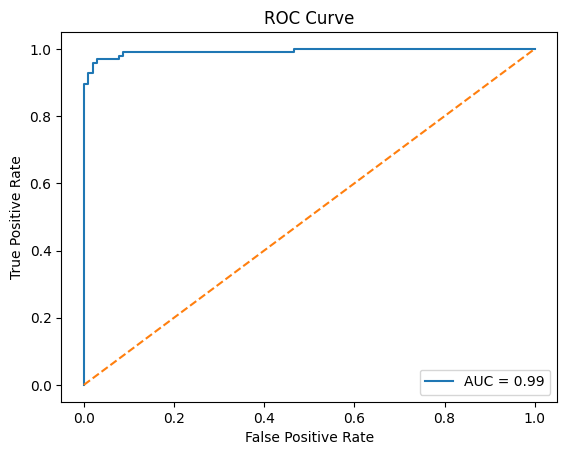

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()